# Agentic AI-OPS Driven Automated Managed Services (AMS) MVP
## End-to-End Autonomous Resolution Pipeline
This notebook implements a sophisticated architectural prototype for modern AMS, moving from reactive ticketing to **Agentic, Knowledge-Driven Orchestration**.

### Core Architecture Pillars:
1. **Semantic Clustering**: Pattern recognition using high-dimensional embeddings.
2. **Strategic Prioritization**: Business-impact-driven automation focus.
3. **Knowledge Article (KA) Synthesis**: Automated 'Step-by-Step' guidance for AI agents.
4. **Enterprise Knowledge Graph (EKG)**: The system's 'Long-term Memory'.
5. **Agentic Orchestrator (The Brain)**: Dynamic plan generation and execution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sentence_transformers import SentenceTransformer
import hdbscan
from collections import Counter
import json

# Aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)

e:\AIML\GoogleAntigravity_proj\ColabNotebooks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Data Ingestion & Enrichment
Loading the high-fidelity synthetic AMS dataset (SAP/Oracle incidents).

In [2]:
# Load the enriched dataset
df = pd.read_csv('datasets/ams_incidents_sap.csv')
print(f"Loaded {len(df)} AMS incidents.")

# Severity Mapping for weighting
severity_map = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df['Sev_Score'] = df['Severity'].map(severity_map)
df.head()

Loaded 1000 AMS incidents.


,Ticket_ID,System,Document,Severity,RCA_Category,Manual_Remediation,Timestamp,Business_Impact,Sev_Score
0,INC-10000,Identity Access,Data sync failure between Identity Access and ...,High,Sync Agent,Flush sync buffer,2026-02-12 15:00:00,1,3
1,INC-10001,Identity Access,Access denied for user in Identity Access. Rep...,Medium,Permissions,Update IAM policy for Identity Access,2026-01-07 06:00:00,3,2
2,INC-10002,SAP ERP,Memory limit exceeded in SAP ERP. Intermittent...,Critical,Resource,Scale up SAP ERP instance,2026-03-20 18:00:00,5,4
3,INC-10003,Identity Access,Data sync failure between Identity Access and ...,High,Sync Agent,Flush sync buffer,2026-02-19 01:00:00,4,3
4,INC-10004,Oracle DB,Connection timeout in Oracle DB. Intermittent ...,High,Network/DB,Restart Oracle DB services,2026-01-27 11:00:00,1,3


## Step 2: Semantic Clustering (Requirement 1)
Utilizing SBERT and HDBSCAN for rapid pattern identification.

In [3]:
# 1. Embeddings
model = SentenceTransformer('all-MiniLM-L6-v2') 
embeddings = model.encode(df['Document'].tolist(), show_progress_bar=True)

# 2. Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')
df['Cluster'] = clusterer.fit_predict(embeddings)

print(f"Identified {len(set(df['Cluster'])) - (1 if -1 in df['Cluster'] else 0)} systemic issue patterns.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7424.70it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:01<00:00, 19.27it/s]


Identified 30 systemic issue patterns.


## Step 3: Strategic Prioritization (Requirement 2)
Ranking clusters by Business Impact (Volume x Severity).

C:\Users\zisha\AppData\Local\Temp\ipykernel_15768\1217148066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=priority_df, x='Priority_Score', y=priority_df['Cluster'].astype(str), palette='magma')


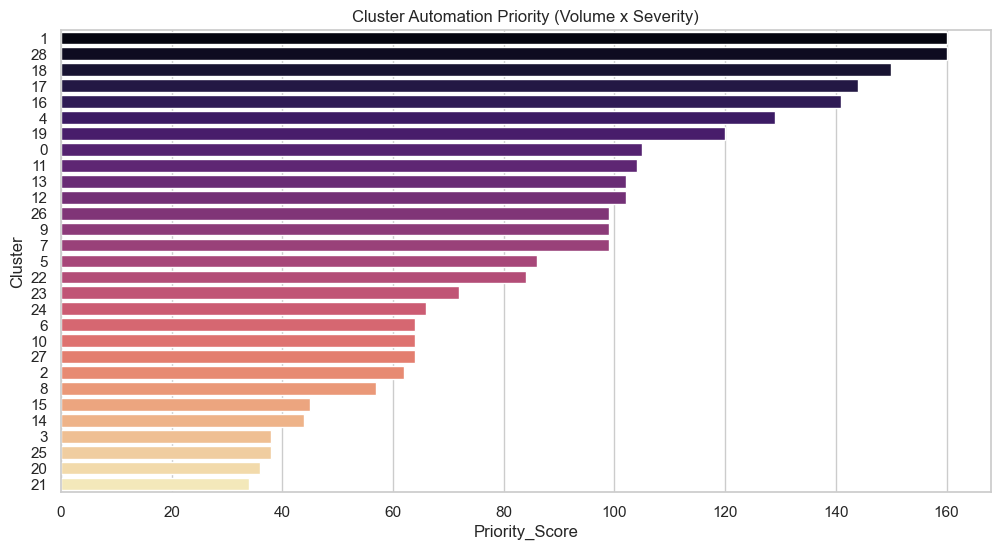

In [4]:
# Aggregating metrics per cluster
cluster_stats = df.groupby('Cluster').agg({
    'Ticket_ID': 'count',
    'Sev_Score': 'mean',
    'Business_Impact': 'mean'
}).rename(columns={'Ticket_ID': 'Volume', 'Sev_Score': 'Avg_Severity'})

# Heatmap Prioritization Score
cluster_stats['Priority_Score'] = cluster_stats['Volume'] * cluster_stats['Avg_Severity']
cluster_stats = cluster_stats.sort_values(by='Priority_Score', ascending=False).reset_index()

# Filter out noise cluster (-1)
priority_df = cluster_stats[cluster_stats['Cluster'] != -1]

plt.figure(figsize=(12, 6))
sns.barplot(data=priority_df, x='Priority_Score', y=priority_df['Cluster'].astype(str), palette='magma')
plt.title('Cluster Automation Priority (Volume x Severity)')
plt.show()

## Step 4: Knowledge Article (KA) Synthesis (Requirement 3)
Generating structured automation guidance for all identified clusters.

In [5]:
def generate_ka(cluster_id, data):
    subset = data[data['Cluster'] == cluster_id]
    top_rca = subset['RCA_Category'].mode()[0]
    top_remediation = subset['Manual_Remediation'].mode()[0]
    
    ka = {
        'KA_ID': f"KA-{1000 + int(cluster_id)}",
        'Target_Issue': f"Automated Resolution for pattern {cluster_id}",
        'Root_Cause': top_rca,
        'Steps': [
            "1. Validate system health for " + str(subset['System'].iloc[0]),
            "2. Execute Remediation: " + str(top_remediation),
            "3. Verify operational heartbeat",
            "4. Close ticket and log to AIOps DB"
        ],
        'Assigned_Agent': "AMS_Auto_Bot_v1" if subset['Business_Impact'].mean() < 4 else "Expert_Hybrid_Agent"
    }
    return ka

# Register KAs for ALL non-noise clusters to ensure full EKG coverage
ka_registry = {}
for cid in priority_df['Cluster']: 
    ka_registry[cid] = generate_ka(cid, df)

print(f"Synthesized {len(ka_registry)} Knowledge Articles and added to registry.")

Synthesized 29 Knowledge Articles and added to registry.


## Step 5: Enterprise Knowledge Graph (EKG) (Requirement 4)
Building the 'System Brain' that maps issues to resolutions.

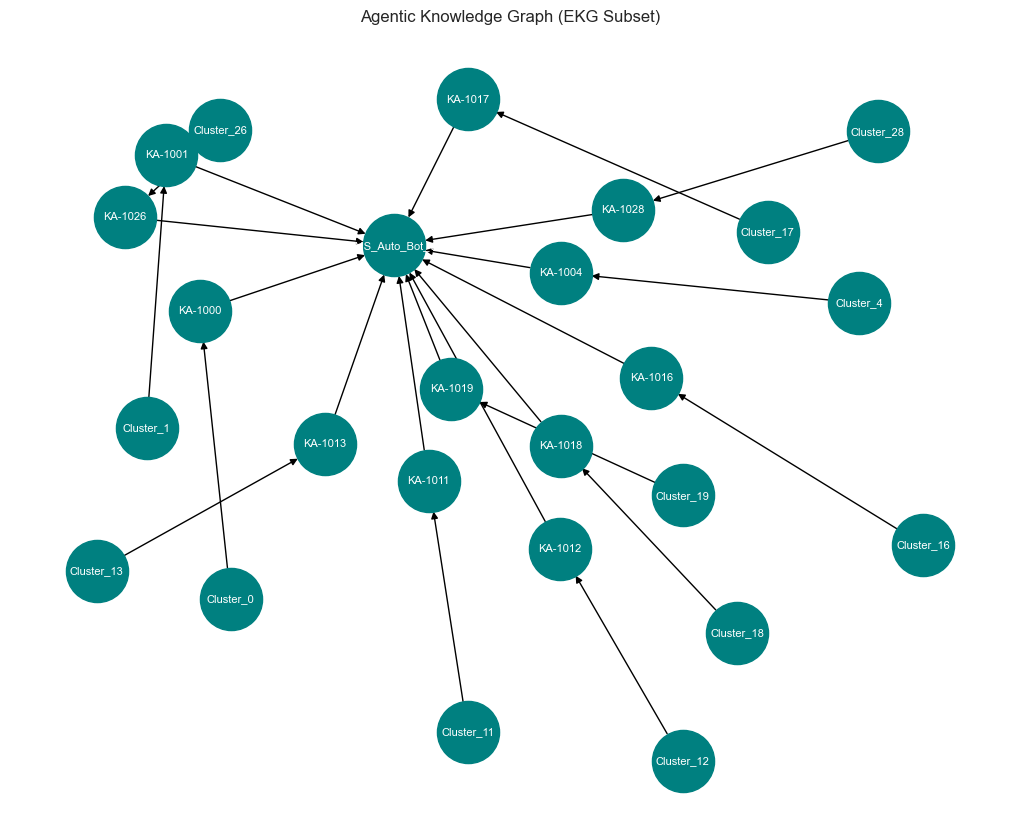

In [9]:
EKG = nx.DiGraph()

for cid, ka in ka_registry.items():
    EKG.add_node(f"Cluster_{cid}", type='Cluster', label=f"Issue Pattern {cid}")
    EKG.add_node(ka['KA_ID'], type='Knowledge_Article', label=ka['Target_Issue'])
    EKG.add_node(ka['Assigned_Agent'], type='Agent', label=ka['Assigned_Agent'])
    
    # Connect
    EKG.add_edge(f"Cluster_{cid}", ka['KA_ID'], relation='Resolved_By')
    EKG.add_edge(ka['KA_ID'], ka['Assigned_Agent'], relation='Executed_By')

# Visualize a subset for clarity
subset_nodes = list(EKG.nodes())[:25]
sub_ekg = EKG.subgraph(subset_nodes)
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_ekg, seed=42)
nx.draw(sub_ekg, pos, with_labels=True, node_size=2000, node_color='teal', font_color='white', font_size=8)
plt.title("Agentic Knowledge Graph (EKG Subset)")
plt.show()

## Step 6: The AI-OPS Brain - Plan Generation & Execution
Simulating the Orchestrator responding to a new, live incident.

In [7]:
class AIOpsOrchestrator:
    def __init__(self, model, embeddings, ekg, ka_registry, df):
        self.model = model
        self.kb_embeddings = embeddings
        self.ekg = ekg
        self.ka_registry = ka_registry
        self.df = df
        
    def handle_incident(self, incident_text):
        print(f"--- [NEW INCIDENT RECEIVED] ---")
        print(f"DESCRIPTION: {incident_text}\n")
        
        # 1. Semantic Search for Cluster
        query_vec = self.model.encode([incident_text])
        sims = np.dot(self.kb_embeddings, query_vec.T).flatten()
        nearest_idx = np.argmax(sims)
        matched_cluster = self.df.iloc[nearest_idx]['Cluster']
        
        print(f"1. ANALYZING: Matching to Cluster {matched_cluster}")
        
        # 2. EKG Traversal for Knowledge Article
        if matched_cluster in self.ka_registry:
            ka = self.ka_registry[matched_cluster]
            print(f"2. RETRIEVING: Found Knowledge Article {ka['KA_ID']}")
            
            # 3. Plan Generation
            print(f"3. GENERATING EXECUTION PLAN...")
            plan = {
                "Title": f"Autonomous Plan for: {incident_text[:30]}...",
                "KA_Source": ka['KA_ID'],
                "Primary_Agent": ka['Assigned_Agent'],
                "Actions": ka['Steps'],
                "Risk_Control": "Human Approval Required" if ka['Assigned_Agent'] == "Expert_Hybrid_Agent" else "Fully Autonomous"
            }
            return plan
        else:
            return {"Status": "Escalate to Human: Pattern not yet prioritized for automation."}

# Initialize the Brain
brain = AIOpsOrchestrator(model, embeddings, EKG, ka_registry, df)

# SIMULATION: A new SAP DB Error occurs
sample_alert = "SAP ERP Database connection timed out intermittently. Error 504."
final_plan = brain.handle_incident(sample_alert)

print("\n--- [FINAL EXECUTION PLAN] ---")
print(json.dumps(final_plan, indent=2))

--- [NEW INCIDENT RECEIVED] ---
DESCRIPTION: SAP ERP Database connection timed out intermittently. Error 504.

1. ANALYZING: Matching to Cluster 19
2. RETRIEVING: Found Knowledge Article KA-1019
3. GENERATING EXECUTION PLAN...

--- [FINAL EXECUTION PLAN] ---
{
  "Title": "Autonomous Plan for: SAP ERP Database connection ti...",
  "KA_Source": "KA-1019",
  "Primary_Agent": "AMS_Auto_Bot_v1",
  "Actions": [
    "1. Validate system health for SAP ERP",
    "2. Execute Remediation: Restart SAP ERP services",
    "3. Verify operational heartbeat",
    "4. Close ticket and log to AIOps DB"
  ],
  "Risk_Control": "Fully Autonomous"
}


## Business Outcome
- **Reduced Repetition**: Clustering identifies systemic issues before they escalate.
- **Faster MTTR**: Automated KAs and Agents immediately know the 'Next Best Action'.
- **Scalable Operations**: The EKG allows the system to learn from every incident and human refinement.